# Experimental Validation

Experimental Setup

| Parameter Value | Description |
| --- | --- |
| Participants | 3 Users |
| Wearable Devices | 3 Garmin Vìvoactive 5 |
| Monitored Rooms | 3 (Home, Lab, Library) |
| Sensing Units | 1 Raspberry Pi 4 sensing unit |
| Observation Period | ≈ 30 days |
| Study Sessions | 09:00 – 18:00 (Active Monitoring) |
| Sleep Sessions | 23:00 – 07:00 |
| Target Sampling | Minute-level aggregation |

## Dataframe Preparation

Starting from the CSVs collected by the framework, we build two aligned datasets: 
- one for study/work hours 
- one for the sleep scores.

We clean and standardize timestamps, enrich wearable data with environmental signals if missing, and remove noisy or empty rows.

In [1]:
from pymongo import MongoClient
from dotenv import load_dotenv
import pandas as pd
import glob
import os

load_dotenv()

True

In [2]:
mongo_uri = os.getenv("MONGO_URI")
db_name = os.getenv("MONGO_DB")
collection = os.getenv("MONGO_COLLECTION")

csv_path = os.getenv("CSV_PATH")
study_df_path = os.getenv("STUDY_DF_PATH")
sleep_df_path = os.getenv("SLEEP_DF_PATH")


In [3]:
fusion_files = glob.glob(csv_path + '/df_fusion_*.csv')
sleep_files = glob.glob(csv_path + '/df_sleep_*.csv')

print(f"Fusion files found: {len(fusion_files)}")

Fusion files found: 250


Connect to MongoDB database

In [4]:
client = MongoClient(mongo_uri)
db = client[db_name]
sensor_collection = db[collection]

### DF for study/work hours

Before concatenation, we align wearable CSVs with environmental measurements.
Some files were collected before the environmental pipeline fix, so they may miss ambient signals.
The helper below restores missing context by merging with MongoDB when needed.

In [5]:
def add_environm_files(files, db):
    """
    Ensure each wearable CSV includes environmental signals when available.

    Some files were collected before the system implementation fix and may
    lack ambient data. This function retrieves the matching environmental
    records from MongoDB and merges them with wearable data on the closest
    previous timestamp. If no merge is needed, the original wearable data is
    returned unchanged.
    """
    processed_df_list = []
    collection = db["sensors_data_collection"]

    for file in files:
        # Load wearable file (CSV)
        df_wearable = pd.read_csv(file)
        df_wearable['timestamp_local'] = pd.to_datetime(df_wearable['timestamp_local'])
        df_wearable = df_wearable.sort_values('timestamp_local')

        if 'room' not in df_wearable.columns or df_wearable.empty:
            processed_df_list.append(df_wearable)
            continue
            
        current_room = df_wearable['room'].iloc[0]

        # Logic specific to the 'lab' room
        if current_room == 'lab':
            start_ts = df_wearable['timestamp_local'].min().strftime('%Y-%m-%d %H:%M:%S')
            end_ts = df_wearable['timestamp_local'].max().strftime('%Y-%m-%d %H:%M:%S')
            query = { 
                "room_name": "lab", 
                "timestamp": { "$gte": start_ts, "$lte": end_ts }
            }
            
            docs = list(collection.find(query))

            if docs:
                # Create environmental DataFrame
                df_ambient = pd.DataFrame(docs)
                df_ambient['timestamp'] = pd.to_datetime(df_ambient['timestamp']).dt.tz_localize(None)
                df_ambient = df_ambient.sort_values('timestamp')

                # Drop unused DB columns
                cols_to_drop_db = ['_id', 'room', 'mqtt_topic', 'room_name']
                df_ambient = df_ambient.drop(columns=[c for c in cols_to_drop_db if c in df_ambient.columns])
                # to avoid duplicate columns during merge.
                cols_overlap = [c for c in df_ambient.columns if c in df_wearable.columns and c != 'timestamp']
                if cols_overlap:
                    df_wearable = df_wearable.drop(columns=cols_overlap)

                # ASYNC MERGE
                df_final = pd.merge_asof(
                    df_wearable,
                    df_ambient,
                    left_on='timestamp_local',
                    right_on='timestamp',
                    direction='backward'
                )
                if 'timestamp' in df_final.columns:
                    df_final = df_final.drop(columns=['timestamp'])

                # Fill missing values
                df_final = df_final.ffill().bfill()
                processed_df_list.append(df_final)
            else:
                processed_df_list.append(df_wearable)
        else:
            processed_df_list.append(df_wearable)

    return processed_df_list

In [6]:
def concatenate_csv(files):
    enriched_list = add_environm_files(files, db)

    all_dfs = [df for df in enriched_list if not df.empty]
    combined_df = pd.concat(all_dfs, ignore_index=True)

    # Convert timestamp_local to datetime to avoid type mismatch
    combined_df['timestamp_local'] = pd.to_datetime(combined_df['timestamp_local'])
    combined_df = combined_df.drop(columns=['hrv'], errors='ignore')    
    ordered_df = combined_df.sort_values(['timestamp_local', 'garmin_id'])

    # Remove rows with null or zero values for the specified sensors
    sensor_cols = ['temperature_DHT22_C', 'humidity_DHT22_%', 'CO2_ppm']
    existing_cols = [col for col in sensor_cols if col in ordered_df.columns]
    for col in existing_cols:
        ordered_df = ordered_df[(ordered_df[col].notna())]
    return ordered_df.reset_index(drop=True)

fusion_df = concatenate_csv(fusion_files)
fusion_df.to_csv(study_df_path, index=False)
print(f"Concatenated DataFrame shape: {fusion_df.shape}")

/tmp/ipykernel_1781750/4062015240.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final = df_final.ffill().bfill()
/tmp/ipykernel_1781750/4062015240.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final = df_final.ffill().bfill()
/tmp/ipykernel_1781750/4062015240.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_fina

Concatenated DataFrame shape: (13790, 14)


### Sleep DF

In [7]:
def concatenate_csv(files):
    df_list = [pd.read_csv(file) for file in files]

    combined_df = pd.concat(df_list, ignore_index=True)

    # Convert timestamp_local to datetime to avoid type mismatch
    combined_df['timestamp_local'] = pd.to_datetime(combined_df['timestamp_local'])
    
    # Remove timezone info if present
    if combined_df['timestamp_local'].dt.tz is not None:
        combined_df['timestamp_local'] = combined_df['timestamp_local'].dt.tz_localize(None)
    
    drop_df = combined_df.drop(columns=['room'], errors='ignore')

    ordered_df = drop_df.sort_values(['timestamp_local', 'garmin_id'])
    return ordered_df.reset_index(drop=True)

sleep_df = concatenate_csv(sleep_files)
sleep_df.to_csv(sleep_df_path, index=False)
print(f"Concatenated DataFrame shape: {sleep_df.shape}")

Concatenated DataFrame shape: (9996, 6)


### Df Study/work hours info

In [12]:
fusion_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13790 entries, 0 to 13789
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp_local      13790 non-null  datetime64[ns]
 1   garmin_id            13790 non-null  object        
 2   room                 13790 non-null  object        
 3   hr                   11237 non-null  float64       
 4   stress_score         5158 non-null   float64       
 5   body_battery         5158 non-null   float64       
 6   activity_type        1018 non-null   object        
 7   intensity            1018 non-null   object        
 8   steps                1018 non-null   float64       
 9   temperature_DHT22_C  13790 non-null  float64       
 10  humidity_DHT22_%     13790 non-null  float64       
 11  CO2_ppm              13790 non-null  float64       
 12  TVOC_ppb             13790 non-null  float64       
 13  respiration_rate     1342 non-n

In [13]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


<Axes: >

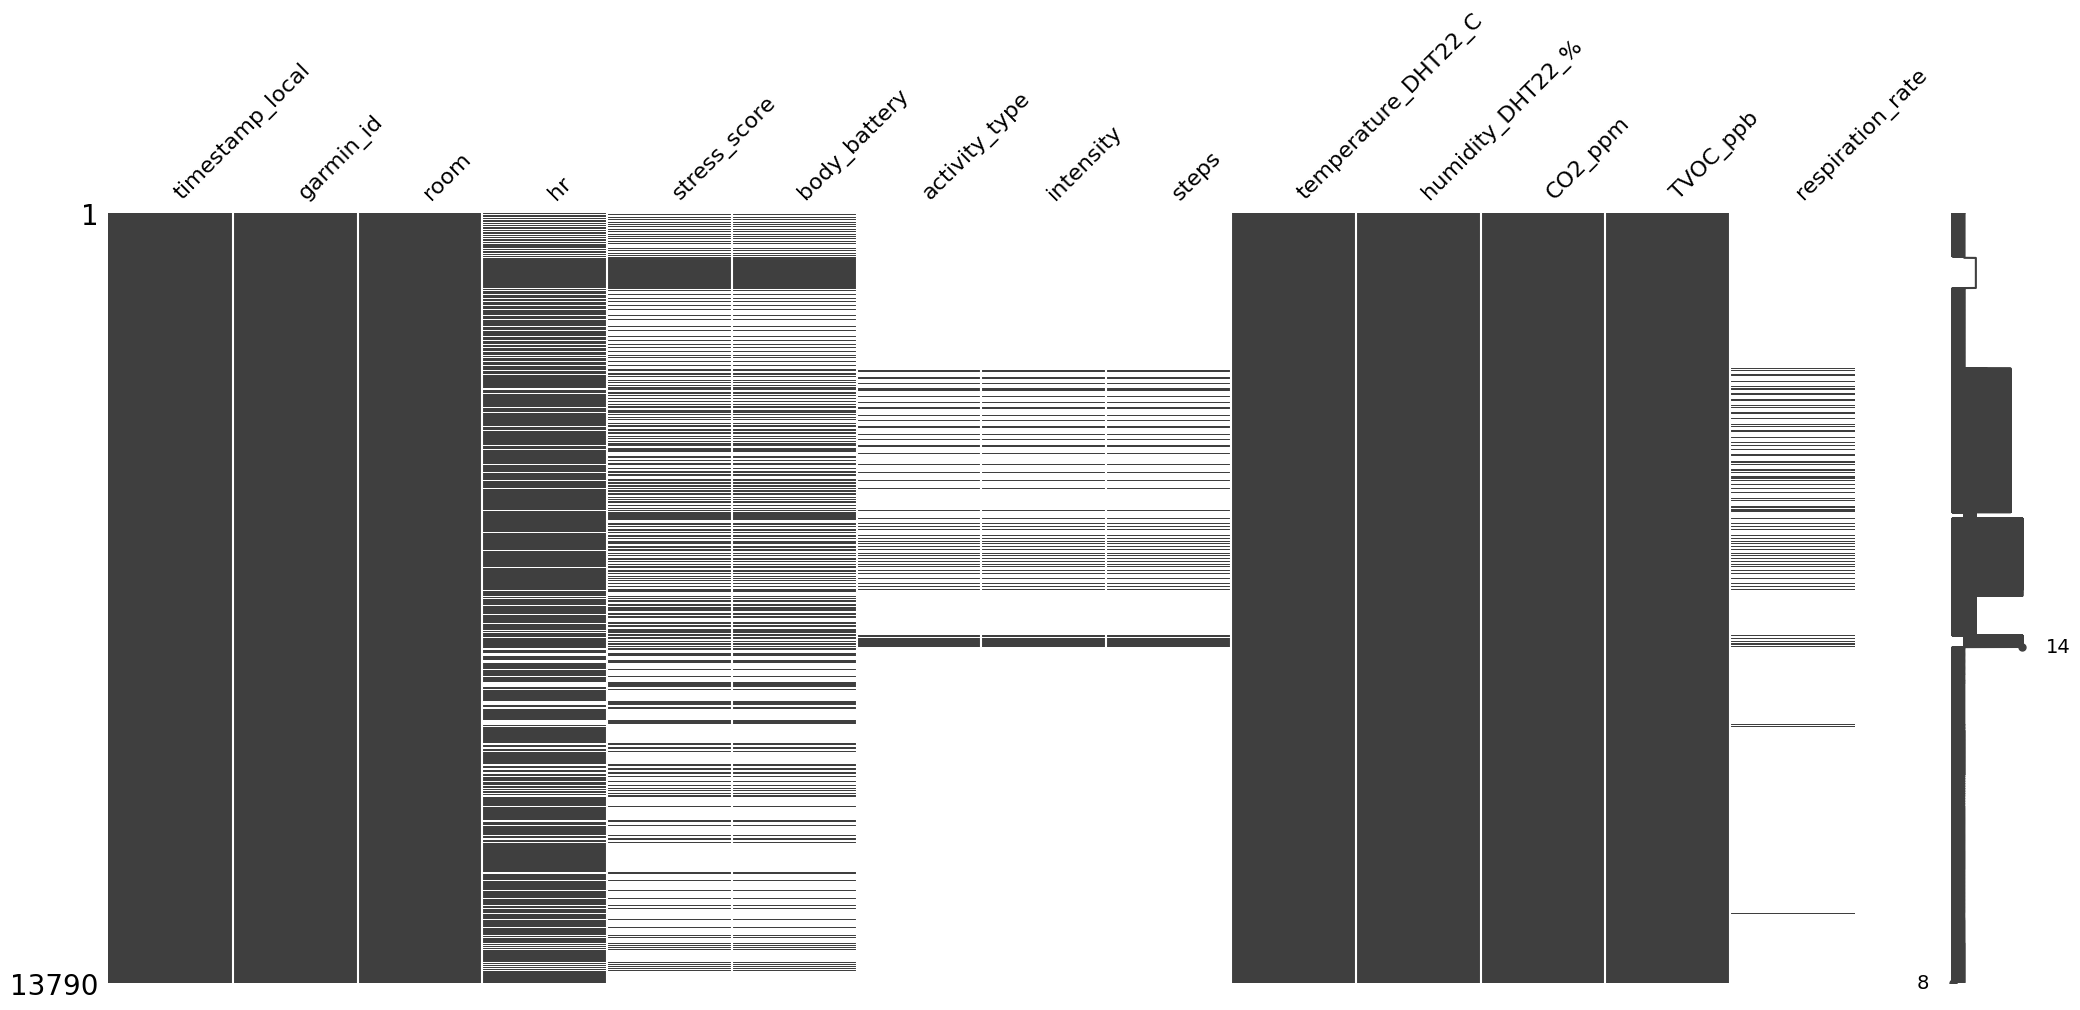

In [14]:
import missingno as msno
msno.matrix(fusion_df)

In [15]:
print(f"Zero count: \n {fusion_df.eq(0).sum()}")
print(f"\n IsNaN count: \n {fusion_df.isna().sum()}")

Zero count: 
 timestamp_local            0
garmin_id                  0
room                       0
hr                         0
stress_score               0
body_battery               0
activity_type              0
intensity                  0
steps                   1018
temperature_DHT22_C        0
humidity_DHT22_%           0
CO2_ppm                    0
TVOC_ppb               10483
respiration_rate           0
dtype: int64

 IsNaN count: 
 timestamp_local            0
garmin_id                  0
room                       0
hr                      2553
stress_score            8632
body_battery            8632
activity_type          12772
intensity              12772
steps                  12772
temperature_DHT22_C        0
humidity_DHT22_%           0
CO2_ppm                    0
TVOC_ppb                   0
respiration_rate       12448
dtype: int64


### Df Sleep Info

In [16]:
sleep_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   timestamp_local         9996 non-null   datetime64[ns]
 1   garmin_id               9996 non-null   object        
 2   sleep_respiration_rate  9996 non-null   float64       
 3   total_sleep_duration    9996 non-null   int64         
 4   deep_sleep_duration     9996 non-null   int64         
 5   sleep_score             9996 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 468.7+ KB
